In [1]:
import matplotlib.pyplot as plt
import numpy as np
from functionsUtils import load_results
#
plt.rc('text', usetex=True)
plt.rc('font', family='Times New Roman')

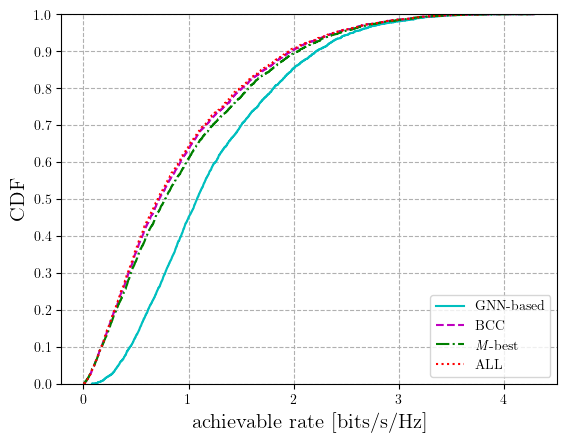

In [52]:
# results = load_results('VARIABLES_SAVED/SE_CDF_Comb_MR_NbrSetups_100_20250103_231841_BPA_Graph.pkl')
#
# Graph = results['Graph'][:]
# BPA = results['BPA'][:]
#
# results = load_results('VARIABLES_SAVED/SE_CDF_Comb_MR_NbrSetups_100_20250104_143837_I_best.pkl')
#
# results = load_results('VARIABLES_SAVED/SE_CDF_Comb_MR_NbrSetups_10_20250103_221225.pkl')
# I_best = results['I_best'][:]

results = load_results('VARIABLES_SAVED/SE_CDF_Comb_MR_NbrSetups_50_20250104_190050.pkl')

Graph = results['Graph'][0][:]
BPA = results['BPA'][0][:]
I_best = results['I_best'][0][:]
ALL = results['ALL'][0][:]




fig, ax = plt.subplots()
plt.grid(visible = True, linestyle='--')

plt.ecdf(Graph, label="GNN-based", color='c')
plt.ecdf(BPA, label="BCC", color='m', linestyle='--')
plt.ecdf(I_best, label=r"\textit{M}-best", color='g', linestyle='-.')
plt.ecdf(ALL, label="ALL", color='r', linestyle=':')

plt.yticks(np.arange(0, 1.10, step=0.1))
#
plt.xlabel(r'achievable rate [bits/s/Hz]', size=15)
plt.ylabel(r'CDF', size=15)
#
plt.legend(fontsize=10, loc='lower right')
plt.draw()
plt.show()

image_format = 'pdf' # e.g .png, .svg, etc.
image_name = 'SEs_CDF_APassignment.pdf'
fig.savefig(image_name, format=image_format, dpi=400)


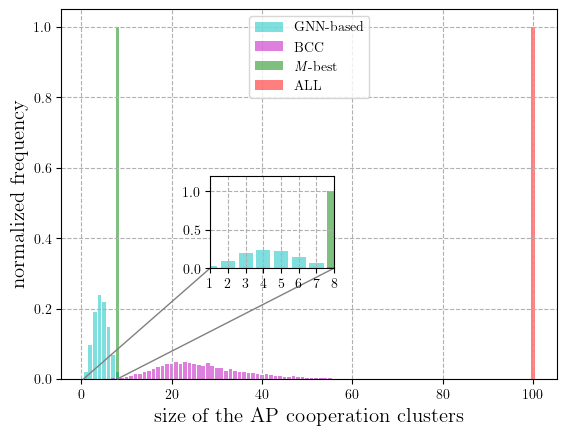

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import ConnectionPatch
from functionsUtils import load_results

results = load_results('VARIABLES_SAVED/SE_CDF_Comb_MR_NbrSetups_50_20250104_190050.pkl')

Graph_nbrServingAPs = results['Graph'][1][:]
BPA_nbrServingAPs = results['BPA'][1][:]
I_best_nbrServingAPs = results['I_best'][1][:]
ALL = results['ALL'][1][:]

max_serv_APs = int(max(max(Graph_nbrServingAPs), max(BPA_nbrServingAPs),
                       max(I_best_nbrServingAPs), max(ALL)))

Graph_nbrServingAPs_hist = np.zeros(max_serv_APs)
BPA_nbrServingAPs_hist = np.zeros(max_serv_APs)
I_best_nbrServingAPs_hist = np.zeros(max_serv_APs)
ALL_nbrServingAPs_hist = np.zeros(max_serv_APs)

for count in range(1, max_serv_APs + 1):
    Graph_nbrServingAPs_hist[count-1] = list(Graph_nbrServingAPs).count(count)/3750
    BPA_nbrServingAPs_hist[count-1] = list(BPA_nbrServingAPs).count(count)/3750
    I_best_nbrServingAPs_hist[count-1] = list(I_best_nbrServingAPs).count(count)/3750
    ALL_nbrServingAPs_hist[count-1] = list(ALL).count(count)/3750

fig, ax = plt.subplots()
# Plot histograms together
plt.bar(np.array(list(range(1, max_serv_APs + 1)), dtype=int), Graph_nbrServingAPs_hist, color='c', alpha=0.5, label='GNN-based')
plt.bar(np.array(list(range(1, max_serv_APs + 1)), dtype=int), BPA_nbrServingAPs_hist, color='m', alpha=0.5, label='BCC')
plt.bar(np.array(list(range(1, max_serv_APs + 1)), dtype=int), I_best_nbrServingAPs_hist, color='g', alpha=0.5, label=r"\textit{M}-best")
plt.bar(np.array(list(range(1, max_serv_APs + 1)), dtype=int), ALL_nbrServingAPs_hist, color='r', alpha=0.5, label='ALL')

plt.xlabel('size of the AP cooperation clusters', size=15)
plt.ylabel('normalized frequency', size=15)
plt.legend(fontsize=10, loc='upper center')
plt.grid(visible=True, linestyle='--')

# Add zoomed inset
axins = ax.inset_axes([0.3, 0.3, 0.25, 0.25])  # [x0, y0, width, height]
axins.bar(np.array(list(range(1, 9)), dtype=int), Graph_nbrServingAPs_hist[:8], color='c', alpha=0.5, label='GNN-based')
axins.bar(np.array(list(range(1, 9)), dtype=int), BPA_nbrServingAPs_hist[:8], color='m', alpha=0.5, label='BPA')
axins.bar(np.array(list(range(1, 9)), dtype=int), I_best_nbrServingAPs_hist[:8], color='g', alpha=0.5, label=r"\textit{M}-best")
axins.bar(np.array(list(range(1, 9)), dtype=int), ALL_nbrServingAPs_hist[:8], color='r', alpha=0.5, label='ALL')

axins.set_xlim(1, 8)
axins.set_ylim(0, max(max(Graph_nbrServingAPs_hist[:8]), max(BPA_nbrServingAPs_hist[:8]), max(I_best_nbrServingAPs_hist[:8]), max(ALL_nbrServingAPs_hist[:8])) * 1.2)
axins.set_xticks(np.arange(1, 9, step=1))
axins.grid(visible=True, linestyle='--')

# Add lines to indicate zoom
xy1 = (1, 0)  # bottom-left corner of the zoom
xy2 = (8, 0)  # bottom-right corner of the zoom
con1 = ConnectionPatch(xyA=xy1, xyB=(0.5, 0), coordsA="data", coordsB="data", axesA=axins, axesB=ax, color="0.5")
con2 = ConnectionPatch(xyA=xy2, xyB=(8, 0), coordsA="data", coordsB="data", axesA=axins, axesB=ax, color="0.5")
axins.add_artist(con1)
axins.add_artist(con2)

plt.show()

image_format = 'pdf'  # e.g .png, .svg, etc.
image_name = 'Histogram_APassignment.pdf'
fig.savefig(image_name, format=image_format, dpi=400)

In [9]:
np.histogram(DCC_nbrServingAPs, bins=6)

(array([ 20,   8,  48, 104, 108, 112], dtype=int64),
 array([1., 2., 3., 4., 5., 6., 7.]))